In [ ]:
# step 1 import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')
# set seaborn style
sns.set_style('whitegrid')
%matplotlib inline

In [8]:
# step 2 fetch data
# define date range

tickers = 'RELIANCE.NS'
start_date = '2020-01-01'
end_date = '2025-07-30'

stock_data = yf.download(tickers, start=start_date, end=end_date, progress=False)

# display data
stock_data.head()


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2020-01-01,678.021423,685.881386,676.180003,681.794210,14004468
2020-01-02,689.564270,692.101927,679.099312,679.099312,17710316
2020-01-03,690.395203,692.416334,684.039846,688.531236,20984698
2020-01-06,674.383362,686.240613,672.811358,682.692450,24519177
2020-01-07,684.758545,689.205022,679.773056,682.243314,16683622


In [10]:
stock_data.columns

MultiIndex([( 'Close', 'RELIANCE.NS'),
            (  'High', 'RELIANCE.NS'),
            (   'Low', 'RELIANCE.NS'),
            (  'Open', 'RELIANCE.NS'),
            ('Volume', 'RELIANCE.NS')],
           names=['Price', 'Ticker'])

In [12]:
dates = pd.date_range(start='2020-01-01', end='2020-12-31', freq='B')
np.random.seed(42)
sample_data = {
    'Open': np.random.uniform(1400, 1600, len(dates)),
    'High': np.random.uniform(1450, 1650, len(dates)),
    'Low': np.random.uniform(1100, 1650, len(dates)),
    'Close': np.random.uniform(1400, 1600,len(dates)),
    'Adj_Close': np.random.uniform(1400, 1600, len(dates)),
    'Volume': np.random.randint(100000, 1000000000, len(dates))
}

stock_data = pd.DataFrame(sample_data, index=dates)
stock_data.to_csv('reliance_sample_data.csv')
stock_data.head()

,Open,High,Low,Close,Adj_Close,Volume
2020-01-01,1474.908024,1478.016803,1561.080788,1516.678359,1574.019775,344190630
2020-01-02,1590.142861,1553.665930,1357.781238,1480.170283,1404.253882,690817130
2020-01-03,1546.398788,1625.474614,1328.150726,1492.401161,1574.940335,622082803
2020-01-06,1519.731697,1598.153724,1250.373890,1589.456668,1505.787427,227739503
2020-01-07,1431.203728,1589.403148,1131.006523,1430.670281,1587.813540,204507683


In [16]:
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 262 entries, 2020-01-01 to 2020-12-31
Freq: B
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       262 non-null    float64
 1   High       262 non-null    float64
 2   Low        262 non-null    float64
 3   Close      262 non-null    float64
 4   Adj_Close  262 non-null    float64
 5   Volume     262 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 14.3 KB


In [15]:
stock_data['Volume'] = stock_data['Volume'].astype(np.int64)

In [19]:
stock_data['Daily Returns'] = stock_data['Close'].pct_change() * 100
stock_data.head()

,Open,High,Low,Close,Adj_Close,Volume,Daily Returns
2020-01-01,1474.908024,1478.016803,1561.080788,1516.678359,1574.019775,344190630,NaN
2020-01-02,1590.142861,1553.665930,1357.781238,1480.170283,1404.253882,690817130,-2.407107
2020-01-03,1546.398788,1625.474614,1328.150726,1492.401161,1574.940335,622082803,0.826316
2020-01-06,1519.731697,1598.153724,1250.373890,1589.456668,1505.787427,227739503,6.503312
2020-01-07,1431.203728,1589.403148,1131.006523,1430.670281,1587.813540,204507683,-9.989979


In [21]:
stock_data['Buy'] = np.random.randint(stock_data['Open'], stock_data['Close']) if stock_data['Open'] < stock_data['Close'] else np.random.randint(stock_data['Close'], stock_data['Open'])
stock_data['Sell'] = np.random.randint(stock_data['Open'], stock_data['Close']) if stock_data['Open'] < stock_data['Close'] else np.random.randint(stock_data['Close'], stock_data['Open'])

stock_data.head()

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [26]:
# 20 days
stock_data['20_MA'] = stock_data['Close'].rolling(window=20).mean()

# 50 days
stock_data['50_MA'] = stock_data['Close'].rolling(window=50).mean()

stock_data.tail()

,Open,High,Low,Close,Adj_Close,Volume,Daily Returns,20_MA,50_MA
2020-12-25,1539.205959,1480.083378,1398.498444,1525.178275,1574.193825,510792999,4.196601,1497.503307,1508.570968
2020-12-28,1514.012234,1568.826143,1238.489482,1577.195550,1542.817386,492341198,3.410570,1496.920419,1510.670983
2020-12-29,1419.435299,1526.178171,1290.132796,1523.172638,1560.345617,303366535,-3.425251,1498.336909,1512.768108
2020-12-30,1523.001445,1643.982880,1199.878744,1446.591895,1467.890039,79640080,-5.027713,1492.046077,1510.030691
2020-12-31,1598.010770,1618.423785,1599.647809,1404.880156,1562.965023,130611435,-2.883449,1483.844591,1509.581020


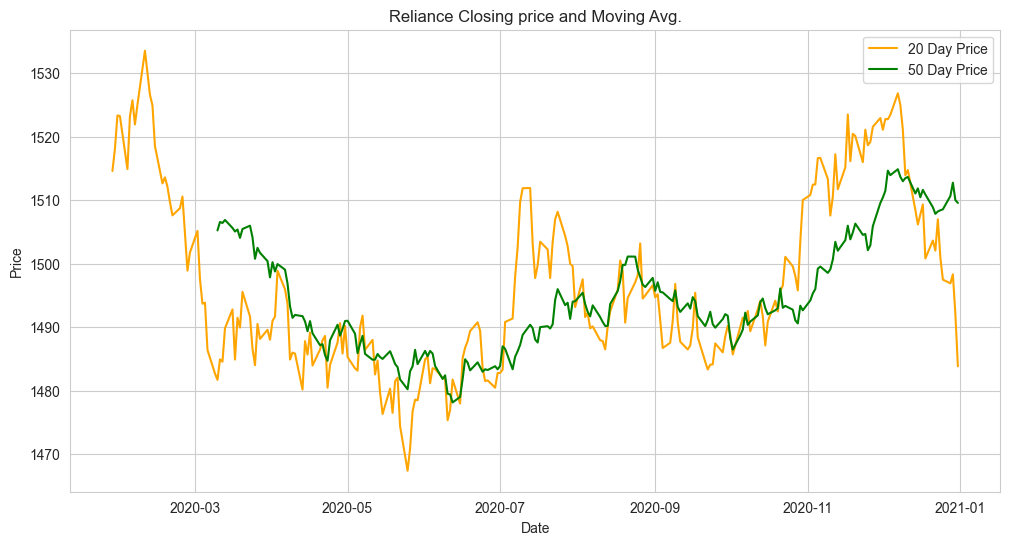

In [27]:
plt.figure(figsize=(12, 6))
# plt.plot(stock_data['Close'], label='Close Price', color='blue')
plt.plot(stock_data['20_MA'], label='20 Day Price', color='orange')
plt.plot(stock_data['50_MA'], label='50 Day Price', color='green')
plt.title('Reliance Closing price and Moving Avg.')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

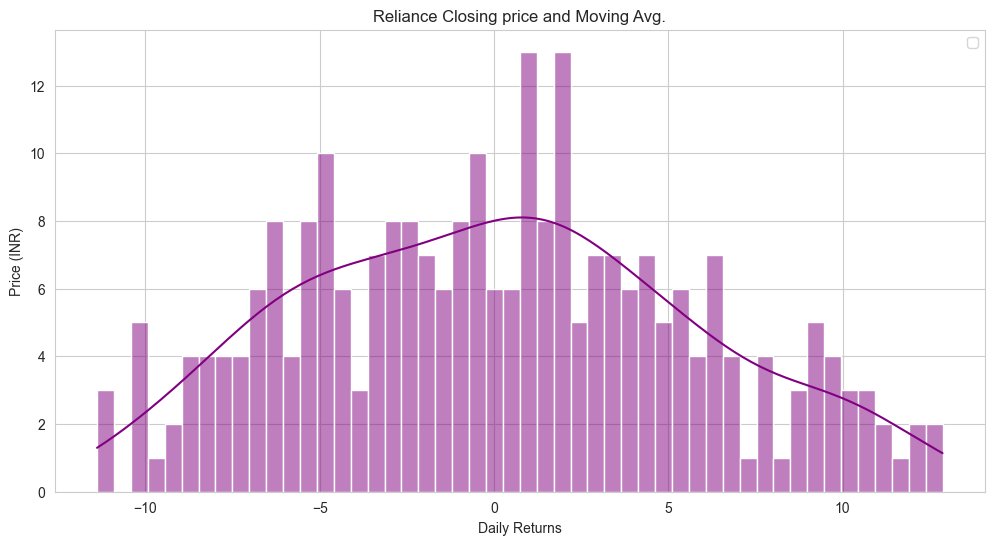

In [31]:
plt.figure(figsize=(12, 6))
sns.histplot(stock_data['Daily Returns'].dropna(), bins=50, kde='True', color='purple')
plt.title('Reliance Closing price and Moving Avg.')
plt.ylabel('Price (INR)')
plt.legend()
plt.grid(True)
plt.show()

In [34]:
stock_data.to_excel('update_stock_data.xlsx')